Predictive Analytics for Customer Churn: Dataset

Context :
This dataset is part of a data science project focused on customer churn prediction for a subscription-based service. Customer churn, the rate at which customers cancel their subscriptions, is a vital metric for businesses offering subscription services. Predictive analytics techniques are employed to anticipate which customers are likely to churn, enabling companies to take proactive measures for customer retention.

Content :
This dataset contains anonymized information about customer subscriptions and their interaction with the service. The data includes various features such as subscription type, payment method, viewing preferences, customer support interactions, and other relevant attributes. It consists of three files such as "test.csv", "train.csv", "data_descriptions.csv"

Columns :

CustomerID: Unique identifier for each customer

SubscriptionType: Type of subscription plan chosen by the customer (e.g., Basic, Premium, Deluxe)

PaymentMethod: Method used for payment (e.g., Credit Card, Electronic Check, PayPal)

PaperlessBilling: Whether the customer uses paperless billing (Yes/No)

ContentType: Type of content accessed by the customer (e.g., Movies, TV Shows, Documentaries)

MultiDeviceAccess: Whether the customer has access on multiple devices (Yes/No)

DeviceRegistered: Device registered by the customer (e.g., Smartphone, Smart TV, Laptop)

GenrePreference: Genre preference of the customer (e.g., Action, Drama, Comedy)

Gender: Gender of the customer (Male/Female)

ParentalControl: Whether parental control is enabled (Yes/No)

SubtitlesEnabled: Whether subtitles are enabled (Yes/No)

AccountAge: Age of the customer's subscription account (in months)

MonthlyCharges: Monthly subscription charges

TotalCharges: Total charges incurred by the customer

ViewingHoursPerWeek: Average number of viewing hours per week

SupportTicketsPerMonth: Number of customer support tickets raised per month

AverageViewingDuration: Average duration of each viewing session

ContentDownloadsPerMonth: Number of content downloads per month

UserRating: Customer satisfaction rating (1 to 5)

WatchlistSize: Size of the customer's content watchlist

https://www.kaggle.com/datasets/safrin03/predictive-analytics-for-customer-churn-dataset?resource=download&select=train.csv

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df=pd.read_csv("train.csv")

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [31]:
#CUSTOMERID NOT IMP FOR MODELING

df.drop("CustomerID", axis=1, inplace=True)

In [32]:
df.shape

(243787, 20)

In [33]:
df.isnull().sum()

AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
Churn                       0
dtype: int64

In [34]:
df.dtypes

AccountAge                    int64
MonthlyCharges              float64
TotalCharges                float64
SubscriptionType             object
PaymentMethod                object
PaperlessBilling             object
ContentType                  object
MultiDeviceAccess            object
DeviceRegistered             object
ViewingHoursPerWeek         float64
AverageViewingDuration      float64
ContentDownloadsPerMonth      int64
GenrePreference              object
UserRating                  float64
SupportTicketsPerMonth        int64
Gender                       object
WatchlistSize                 int64
ParentalControl              object
SubtitlesEnabled             object
Churn                         int64
dtype: object

In [35]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.drop('Churn', errors='ignore')
print(numerical_columns)

Index(['AccountAge', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek',
       'AverageViewingDuration', 'ContentDownloadsPerMonth', 'UserRating',
       'SupportTicketsPerMonth', 'WatchlistSize'],
      dtype='object')


In [36]:
for col in df.columns:
  if col not in numerical_columns:
    print(col, df[col].value_counts())
    print("_"*50)


SubscriptionType SubscriptionType
Standard    81920
Basic       81050
Premium     80817
Name: count, dtype: int64
__________________________________________________
PaymentMethod PaymentMethod
Electronic check    61313
Credit card         60924
Bank transfer       60797
Mailed check        60753
Name: count, dtype: int64
__________________________________________________
PaperlessBilling PaperlessBilling
No     121980
Yes    121807
Name: count, dtype: int64
__________________________________________________
ContentType ContentType
Both        81737
TV Shows    81145
Movies      80905
Name: count, dtype: int64
__________________________________________________
MultiDeviceAccess MultiDeviceAccess
No     122035
Yes    121752
Name: count, dtype: int64
__________________________________________________
DeviceRegistered DeviceRegistered
Computer    61147
Tablet      61143
Mobile      60914
TV          60583
Name: count, dtype: int64
__________________________________________________
GenrePre

In [37]:
print(df["Churn"].value_counts())

Churn
0    199605
1     44182
Name: count, dtype: int64


EXPLORATORY DATA ANALYSIS`

TIME BASED BEHAVIOUR ANALYSIS

Churn by Account Age

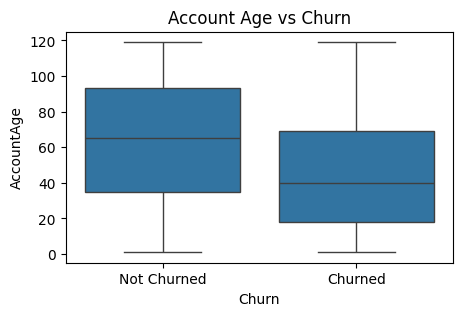

In [38]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['Churn'], y=df['AccountAge'])
plt.title("Account Age vs Churn")
plt.xticks([0, 1], ["Not Churned", "Churned"])
plt.show()

We can see the box plot for not churned is for customers with more Account Age. Thus, proving customers with more account age have lower churn rate.

CHURN SEGMENTATION BY DEMOGRAPHICS AND USAGE BEHAVIOR

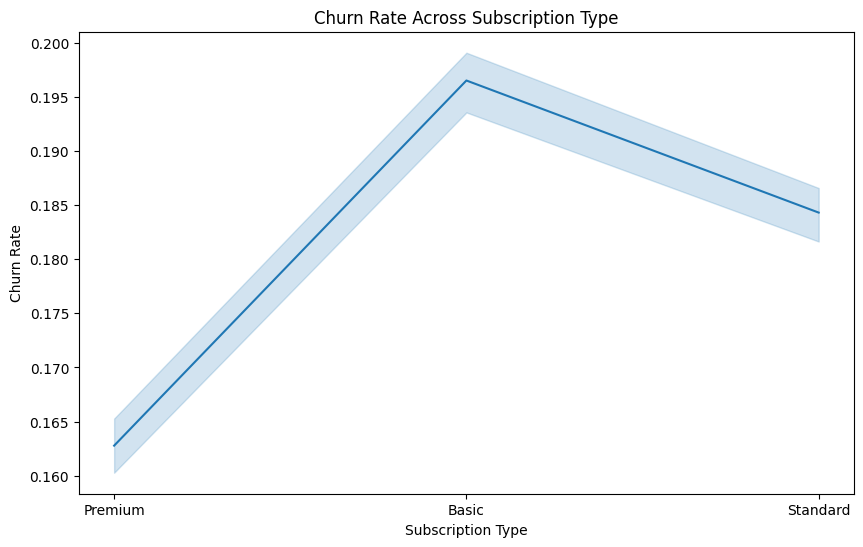

In [39]:
#CHURN VS SUBSCRIPTION TYPE


plt.figure(figsize=(10, 6))
sns.lineplot(x='SubscriptionType', y='Churn', data=df)
plt.title('Churn Rate Across Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Churn Rate')
plt.show()


Basic Subscription tend to churn more

```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Churn Segmentation by Demographics and Usage Behavior
# Example usage
df = pd.read_csv('customer_data.csv')
analyze_churn_by_viewing_behavior(df)
```

In [40]:
# Churn vs Subscription Type
def analyze_churn_by_subscription_type(df):
    churn_rates = df.groupby('SubscriptionType')['Churn'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    sns.barplot(x='SubscriptionType', y='Churn', data=churn_rates)
    plt.title('Churn Rate by Subscription Type')
    plt.xlabel('Subscription Type')
    plt.ylabel('Churn Rate')
    plt.show()

# Churn by Payment Method
def analyze_churn_by_payment_method(df):
    churn_rates = df.groupby('PaymentMethod')['Churn'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    sns.barplot(x='PaymentMethod', y='Churn', data=churn_rates)
    plt.title('Churn Rate by Payment Method')
    plt.xlabel('Payment Method')
    plt.ylabel('Churn Rate')
    plt.show()

# Churn by Viewing Behavior
def analyze_churn_by_viewing_behavior(df):
    df['viewing_behavior'] = pd.cut(df['ViewingHoursPerWeek'], bins=[0, 10, 20, 30, 40], labels=['Low', 'Medium', 'High', 'Very High'])
    churn_rates = df.groupby('viewing_behavior')['Churn'].mean().reset_index()
    plt.figure(figsize=(10, 6))
    sns.barplot(x='viewing_behavior', y='Churn', data=churn_rates)
    plt.title('Churn Rate by Viewing Behavior')
    plt.xlabel('Viewing Behavior')
    plt.ylabel('Churn Rate')
    plt.show()



The subscription type that tend to churn more is Basic, then Standard and last is Premium

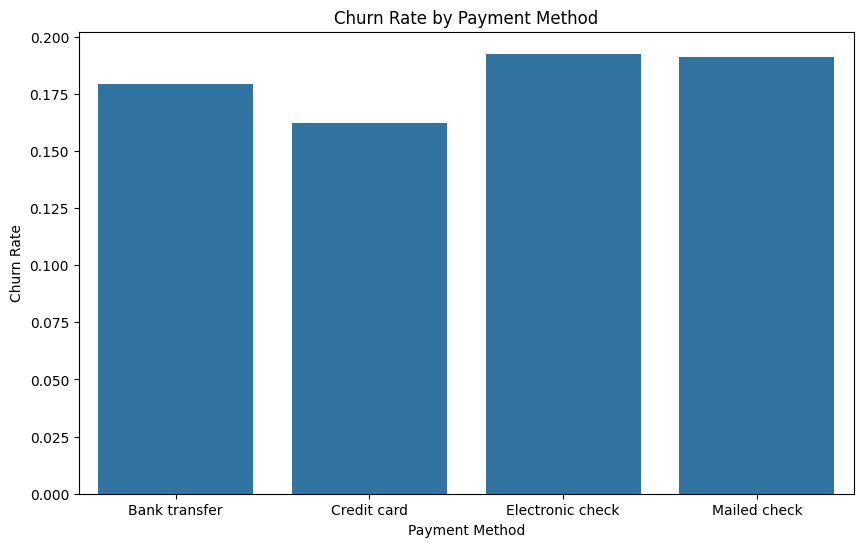

In [41]:
analyze_churn_by_payment_method(df)

The Payment Method type that tend to churn rate is descending order ie Electronic Check, Mailed Check, Bank Transfer and    Credit Card

C:\Users\supep\AppData\Local\Temp\ipykernel_17912\836976692.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rates = df.groupby('viewing_behavior')['Churn'].mean().reset_index()


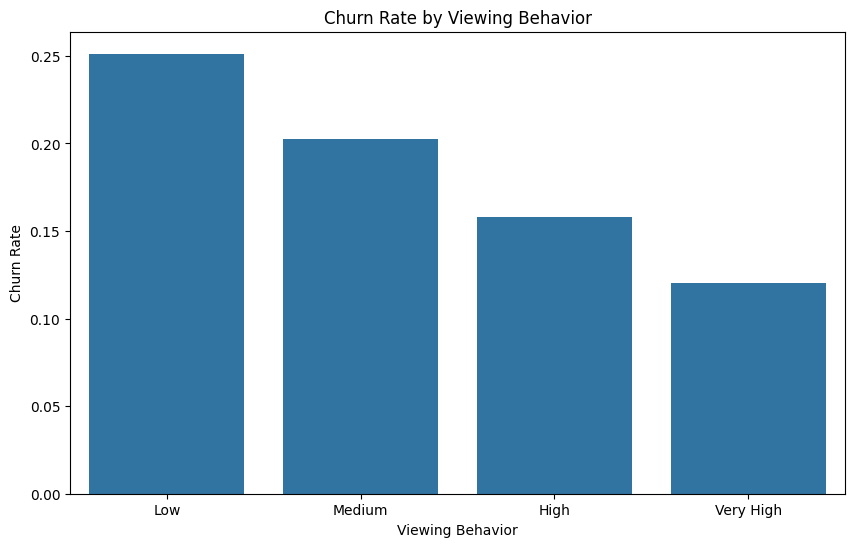

In [42]:
analyze_churn_by_viewing_behavior(df)

More viewing hours means Low Churn Rate

BEHAVIOR AND FEATURE ENGINEERING

                          ContentDownloadsPerMonth  WatchlistSize  UserRating  \
ContentDownloadsPerMonth                  1.000000       0.002324    0.001294   
WatchlistSize                             0.002324       1.000000    0.002567   
UserRating                                0.001294       0.002567    1.000000   
Churn                                    -0.129752       0.021739    0.022124   

                             Churn  
ContentDownloadsPerMonth -0.129752  
WatchlistSize             0.021739  
UserRating                0.022124  
Churn                     1.000000  
    EngagementScore     Churn
0                 0  0.269430
1                 1  0.281768
2                 2  0.226619
3                 3  0.245501
4                 4  0.280295
..              ...       ...
69               69  0.107066
70               70  0.115079
71               71  0.119128
72               72  0.123426
73               73  0.129353

[74 rows x 2 columns]


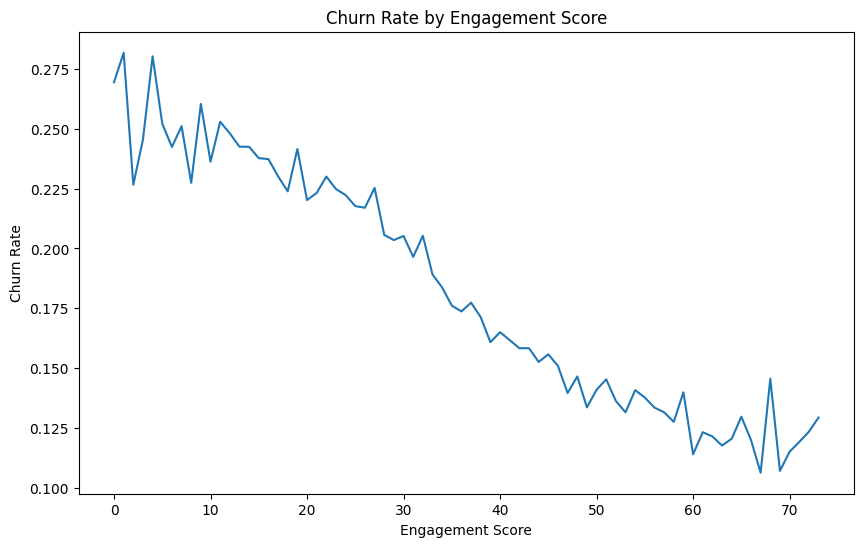

In [43]:
# Engagement Features Analysis
engagement_features = ['ContentDownloadsPerMonth', 'WatchlistSize', 'UserRating']

# Correlation Analysis
correlation_matrix = df[engagement_features + ['Churn']].corr()
print(correlation_matrix)

# Engagement Score Calculation
df['EngagementScore'] = df['ContentDownloadsPerMonth'] + df['WatchlistSize']

# Churn Analysis by Engagement Score
churn_by_engagement = df.groupby('EngagementScore')['Churn'].mean().reset_index()
print(churn_by_engagement)

# Visualize Churn by Engagement Score
plt.figure(figsize=(10,6))
plt.plot(churn_by_engagement['EngagementScore'], churn_by_engagement['Churn'])
plt.xlabel('Engagement Score')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Engagement Score')
plt.show()

CHURN PREDICTION VIA FEATURE RELATIONSHIPS

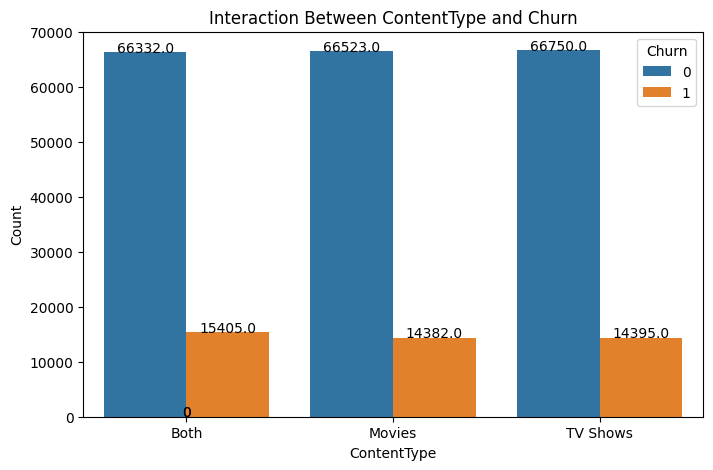

In [44]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='ContentType', hue='Churn', data=df)
plt.title('Interaction Between ContentType and Churn')
plt.xlabel('ContentType')
plt.ylabel('Count')
plt.legend(title='Churn')

# Annotate the bars
for p in ax.patches:
	height = p.get_height()
	ax.text(p.get_x() + p.get_width() / 2., height + 3, height, ha="center")

plt.show()

Boxplot for numerical features
to check outliers

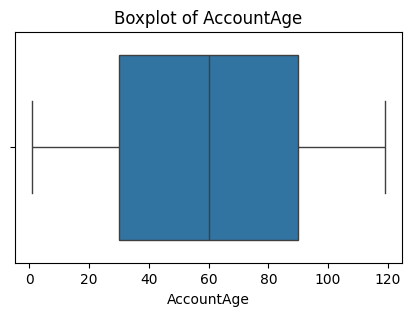

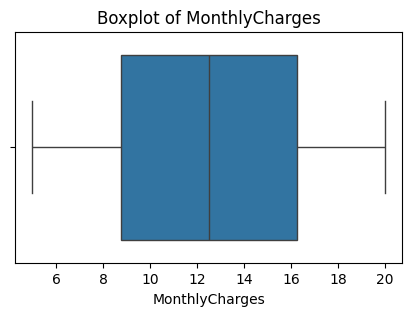

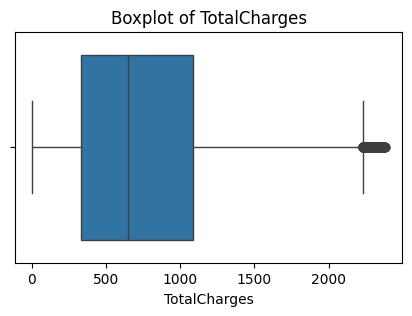

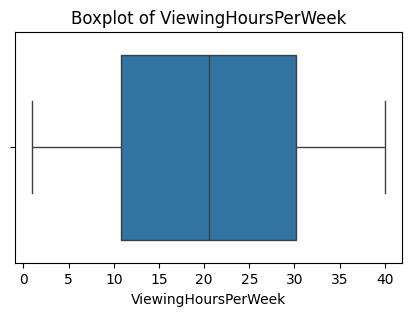

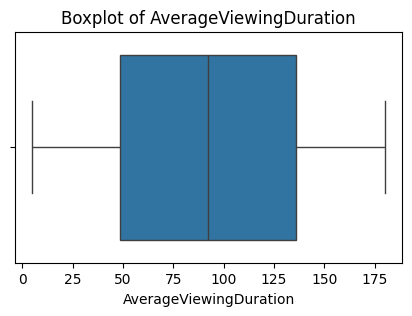

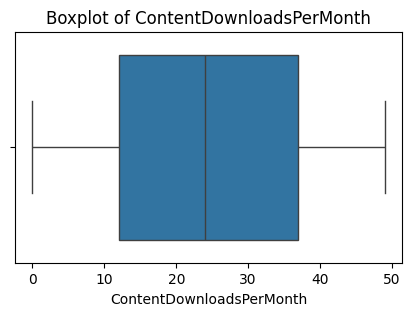

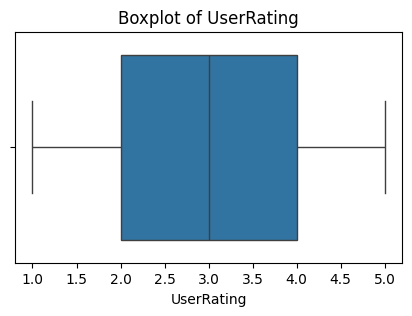

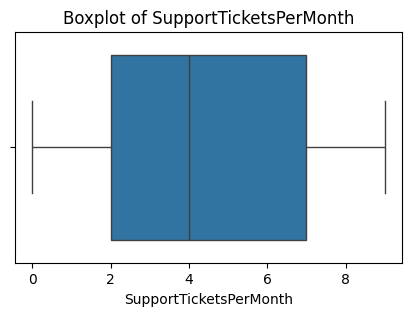

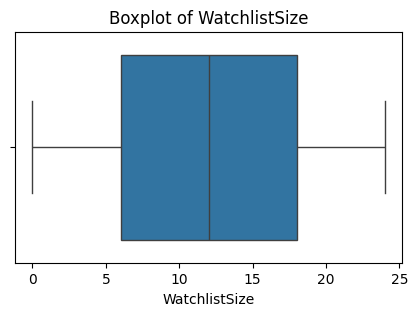

In [45]:
def plot_boxplot(df, column_name):
  plt.figure(figsize=(5,3))
  sns.boxplot(x=df[column_name])
  plt.title(f"Boxplot of {column_name}")
  
for col in numerical_columns:
  plot_boxplot(df,col)

CORRELATION MATRIX

<module 'matplotlib.pyplot' from 'c:\\Users\\supep\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\matplotlib\\pyplot.py'>

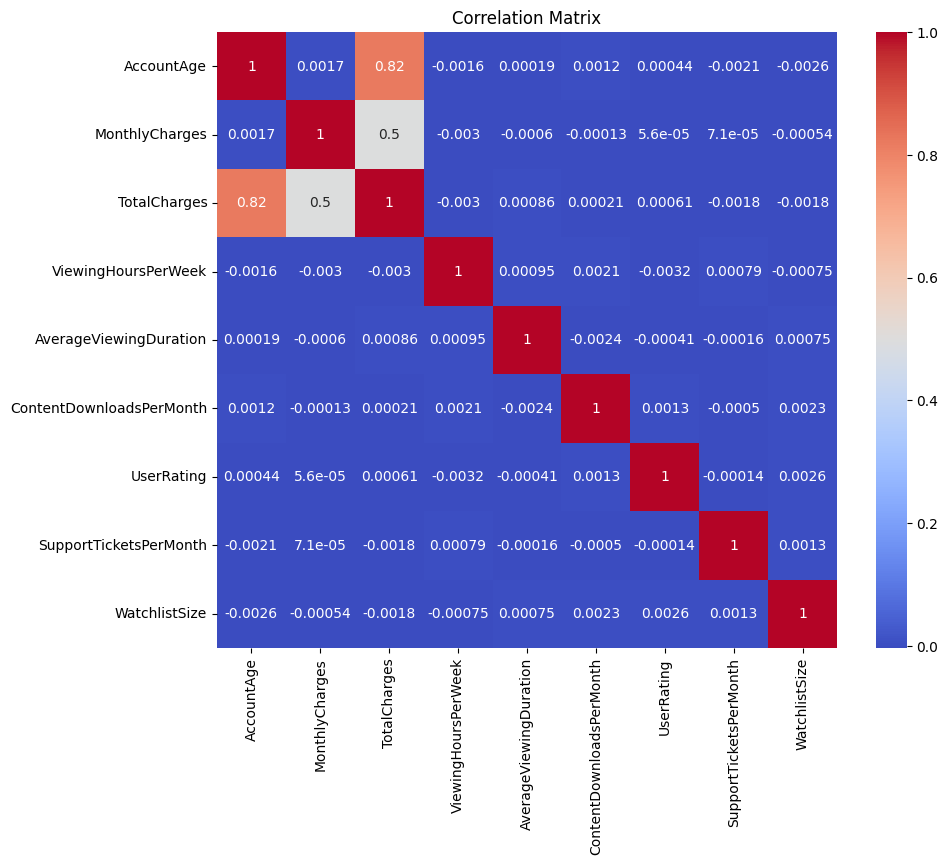

In [46]:
#correlation
plt.figure(figsize=(10,8))
#add churn to numerical_columns
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt

In [47]:
#dropping TotalChatges column as in correlation with AccountAge
df.drop("TotalCharges", axis=1, inplace=True)
df.drop("WatchlistSize", axis=1, inplace=True)

#drop totalcharges from numerical_columns
numerical_columns=numerical_columns.drop("TotalCharges")
numerical_columns=numerical_columns.drop("WatchlistSize")

In [48]:
df.shape

(243787, 20)

In [49]:
categorical_columns=[]
for col in df.columns:
  if col not in numerical_columns:
    categorical_columns.append(col)
#treating Churn as a Catalogical Column

categorical_columns

['SubscriptionType',
 'PaymentMethod',
 'PaperlessBilling',
 'ContentType',
 'MultiDeviceAccess',
 'DeviceRegistered',
 'GenrePreference',
 'Gender',
 'ParentalControl',
 'SubtitlesEnabled',
 'Churn',
 'viewing_behavior',
 'EngagementScore']

COUNT for CATEGORICAL COLUMNS

In [50]:
categorical_columns.remove("Churn")
categorical_columns.remove("viewing_behavior")
categorical_columns.remove("EngagementScore")

df.drop("viewing_behavior", axis=1, inplace=True)
df.drop("EngagementScore", axis=1, inplace=True)

for col in categorical_columns:
  print(df[col].value_counts())

SubscriptionType
Standard    81920
Basic       81050
Premium     80817
Name: count, dtype: int64
PaymentMethod
Electronic check    61313
Credit card         60924
Bank transfer       60797
Mailed check        60753
Name: count, dtype: int64
PaperlessBilling
No     121980
Yes    121807
Name: count, dtype: int64
ContentType
Both        81737
TV Shows    81145
Movies      80905
Name: count, dtype: int64
MultiDeviceAccess
No     122035
Yes    121752
Name: count, dtype: int64
DeviceRegistered
Computer    61147
Tablet      61143
Mobile      60914
TV          60583
Name: count, dtype: int64
GenrePreference
Comedy     49060
Fantasy    48955
Drama      48744
Action     48690
Sci-Fi     48338
Name: count, dtype: int64
Gender
Female    121930
Male      121857
Name: count, dtype: int64
ParentalControl
Yes    122085
No     121702
Name: count, dtype: int64
SubtitlesEnabled
Yes    122180
No     121607
Name: count, dtype: int64


DOING ONE HOT ENCODING FOR OBJECT TYPE COLUMNS

In [51]:
#selecting columns with object type
object_columns=df.select_dtypes(include="object").columns
object_columns

Index(['SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType',
       'MultiDeviceAccess', 'DeviceRegistered', 'GenrePreference', 'Gender',
       'ParentalControl', 'SubtitlesEnabled'],
      dtype='object')

In [52]:

df=pd.get_dummies(df, columns=object_columns, drop_first=True)


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   AccountAge                      243787 non-null  int64  
 1   MonthlyCharges                  243787 non-null  float64
 2   ViewingHoursPerWeek             243787 non-null  float64
 3   AverageViewingDuration          243787 non-null  float64
 4   ContentDownloadsPerMonth        243787 non-null  int64  
 5   UserRating                      243787 non-null  float64
 6   SupportTicketsPerMonth          243787 non-null  int64  
 7   Churn                           243787 non-null  int64  
 8   SubscriptionType_Premium        243787 non-null  bool   
 9   SubscriptionType_Standard       243787 non-null  bool   
 10  PaymentMethod_Credit card       243787 non-null  bool   
 11  PaymentMethod_Electronic check  243787 non-null  bool   
 12  PaymentMethod_Ma

DATA SPLITTING

In [54]:
x=df.drop(columns="Churn")
y=df["Churn"]

In [56]:
from sklearn.model_selection import train_test_split

#splitting train and test data
X_train,X_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [57]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Scale only the numerical columns
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_columns])
X_test_scaled_numerical = scaler.transform(X_test[numerical_columns])

# Convert the scaled numerical data back to DataFrames
X_train = pd.DataFrame(X_train_scaled_numerical, columns=numerical_columns, index=X_train.index)
X_test= pd.DataFrame(X_test_scaled_numerical, columns=numerical_columns, index=X_test.index)


SCALING THE DATA

In [58]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Scale only the numerical columns
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_columns])
X_test_scaled_numerical = scaler.transform(X_test[numerical_columns])

# Convert the scaled numerical data back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled_numerical, columns=numerical_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_numerical, columns=numerical_columns, index=X_test.index)


MODEL TRAINING 

USING LOGISTIC REGRESSION

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

# Initialize Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Fit the model to the training data
logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8242544813158866
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.98      0.90     39968
           1       0.56      0.11      0.18      8790

    accuracy                           0.82     48758
   macro avg       0.70      0.55      0.54     48758
weighted avg       0.79      0.82      0.77     48758



In [70]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

resampled_data = pd.concat([X_train_resampled, pd.Series(y_train_resampled, name='Churn')], axis=1)

X_resampled = resampled_data.drop('Churn', axis=1)
y_resampled = resampled_data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled,
                                                    test_size=0.25,
                                                    random_state=42)

*** After sampling ***
Percentage of 'Churn': 50.0
Percentage of 'Not Churn': 50.0


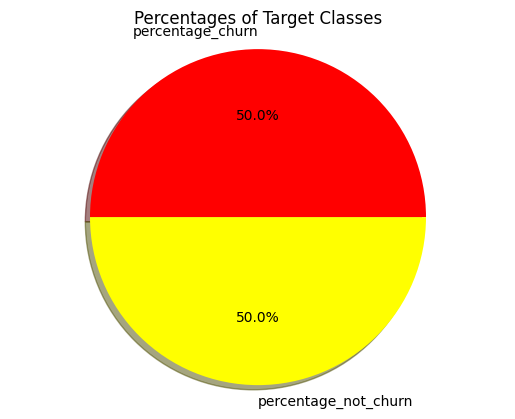

In [71]:
# PIE CHART
churn_count = (resampled_data['Churn'] == 1).sum()
not_churn_count = (resampled_data['Churn'] == 0).sum()

total_count = len(resampled_data)

percentage_churn = (churn_count / total_count) * 100
percentage_not_churn = (not_churn_count / total_count) * 100
print("*** After sampling ***")
print("Percentage of 'Churn':", percentage_churn)
print("Percentage of 'Not Churn':", percentage_not_churn)

# Pasta Grafiği Oluşturma
labels = ['percentage_churn', 'percentage_not_churn']
sizes = [percentage_churn, percentage_not_churn]
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        colors=["red", "yellow"],
        shadow=True)
plt.axis('equal')
plt.title("Percentages of Target Classes")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
y_prob = model.predict_proba(X_test)[:, 1] 

from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

              precision    recall  f1-score   support

           0       0.89      0.86      0.87     40026
           1       0.86      0.89      0.88     39793

    accuracy                           0.87     79819
   macro avg       0.87      0.87      0.87     79819
weighted avg       0.87      0.87      0.87     79819

AUC Score: 0.9476516906259568


In [74]:
print ("accuracy",accuracy_score(y_test, y_pred))

accuracy 0.8741402422981996


Doing PCA and then Random Forest Classifier

In [75]:
from sklearn.decomposition import PCA

#TRYING PCA

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.95)  # Retain 95% variance
pca.fit(X_train)
n_components = int(pca.n_components_)  # Get the number of components and convert to integer
pca = PCA(n_components=n_components)

# Fit and transform the training data, and transform the test data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Convert PCA results back to DataFrame
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(n_components)], index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(n_components)], index=X_test.index)


In [76]:
# Combine PCA features with categorical columns
categorical_columns = [col for col in X_train.columns if col not in numerical_columns]
X_train_final_pca = pd.concat([X_train_pca_df, X_train[categorical_columns]], axis=1)
X_test_final_pca = pd.concat([X_test_pca_df, X_test[categorical_columns]], axis=1)

Accuracy: 0.8470163745474135
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84     40026
           1       0.82      0.88      0.85     39793

    accuracy                           0.85     79819
   macro avg       0.85      0.85      0.85     79819
weighted avg       0.85      0.85      0.85     79819



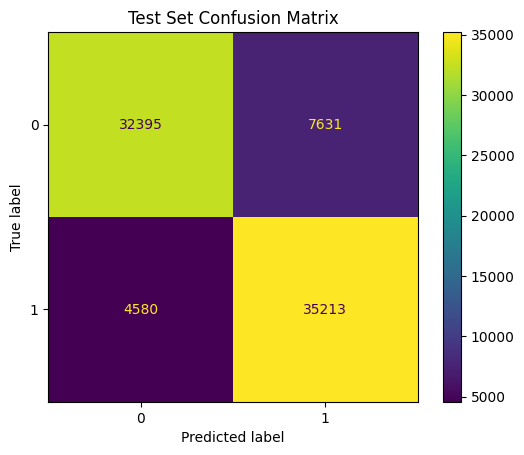

In [77]:
from sklearn.ensemble import RandomForestClassifier


#Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train_final_pca, y_train)

# Step 5: Predict and Evaluate the Model
y_pred = rf.predict(X_test_final_pca)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print('Classification Report:')
print(classification_report(y_test, y_pred))


# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Test Set Confusion Matrix")
plt.show()


So the maximum accuracy i got was 87% above after smoting and training Random Forest. The PCA decreased the results rather than increasing.